# Regressão Robusta: Seleção de Variáveis, Elasticidade e o Modelo Final

O Desafio Minerva-Unifesp-ITA (definição do problema) pede uma curva de demanda
`volume = A · preço⁻ᴮ` para orientar a precificação diária de um SKU ao longo de um horizonte de
2 semanas, dado um histórico de 76 dias de treino (01/08 a 31/10/2025) e 10 dias de teste (03/11 a
14/11/2025, todos dias úteis — nenhum sábado ou domingo aparece no período de teste real). O próprio
enunciado observa que dias da semana diferentes vendem volumes diferentes, e que essa diferença pode
mascarar a relação real entre preço e volume se todos os dias forem tratados como um bloco único —
e que alguns preços ou faixas de preço podem gerar demandas fora do padrão, o que motiva não se
limitar a um ajuste que dê peso total a todo ponto.

Este notebook percorre essas duas perguntas — e uma terceira, o modelo final — em **3 etapas
estritamente ordenadas**, cada uma com testes que a sustentem além de "olhei o gráfico" ou "o p deu
abaixo de 0,05":

- **Etapa 1 — Seleção de variáveis / agrupamento de nível.** O trabalho mais pesado e mais aberto:
  quais dias devem ficar no modelo, se o Fim de Semana deve ser excluído do treino da curva de preço
  inteiramente, e como agrupar o que sobrar — decidido por múltiplos critérios que nem sempre
  concordam entre si, e essa discordância é reportada, não escondida.
- **Etapa 2 — Estrutura de elasticidade** (única / por dia / por grupo), dado o agrupamento de nível
  que a Etapa 1 fechar.
- **Etapa 3 — Modelo de regressão final**, dado a elasticidade escolhida: ajuste por regressão
  robusta, validação de estabilidade e cotejo com uma implementação de referência independente.

**Um ponto de design que fica explícito aqui, não subentendido**: a Etapa 1 (agrupamento de nível) e
a Etapa 2 (estrutura de elasticidade) não são buscas totalmente independentes. Por hierarquia usual
de regressão, um termo de interação preço×grupo só existe depois que "grupo" já é uma variável de
nível — então a elasticidade testada na Etapa 2 fica **aninhada** dentro do agrupamento que a Etapa 1
decidir, em vez de as duas serem buscadas como partições independentes dos dias. Com 76 observações
de treino, buscar as duas coisas de forma totalmente livre multiplicaria o espaço de busca além do
que os dados sustentam — a ordem "nível primeiro, elasticidade depois, aninhada" é uma simplificação
necessária diante do tamanho da amostra, não uma escolha arbitrária.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import StratifiedKFold
import warnings

if not os.path.isdir('data'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

caminho_treino = 'data/interim/.treino.csv'
caminho_teste = 'data/interim/.teste.csv'

df_treino = pd.read_csv(caminho_treino, parse_dates=['Data'])
df_teste = pd.read_csv(caminho_teste, parse_dates=['Data'])

print(f"Treino: {len(df_treino)} dias ({df_treino['Data'].min().date()} a {df_treino['Data'].max().date()})")
print(f"Teste:  {len(df_teste)} dias ({df_teste['Data'].min().date()} a {df_teste['Data'].max().date()})")
print(f"Dias da semana presentes no teste: {sorted(df_teste['Dia da Semana'].unique())}")

Treino: 76 dias (2025-08-01 a 2025-10-31)
Teste:  10 dias (2025-11-03 a 2025-11-14)
Dias da semana presentes no teste: ['Quarta', 'Quinta', 'Segunda', 'Sexta', 'Terça']


## Etapa 1 — Seleção de Variáveis / Agrupamento de Nível

Três perguntas em aberto, nesta ordem: (1) todos os dias devem ficar no modelo, ou algum deveria ser
excluído ou absorvido por outro? (2) o Fim de Semana deveria ser excluído do treino da curva de
preço inteiramente? (3) como agrupar o que sobrar, além de uma leitura de gráfico?

### Leitura inicial: o volume varia por dia da semana?

Ponto de partida, não conclusão — a distribuição por dia da semana só indica se a pergunta vale a
pena ser formalizada nas seções seguintes.

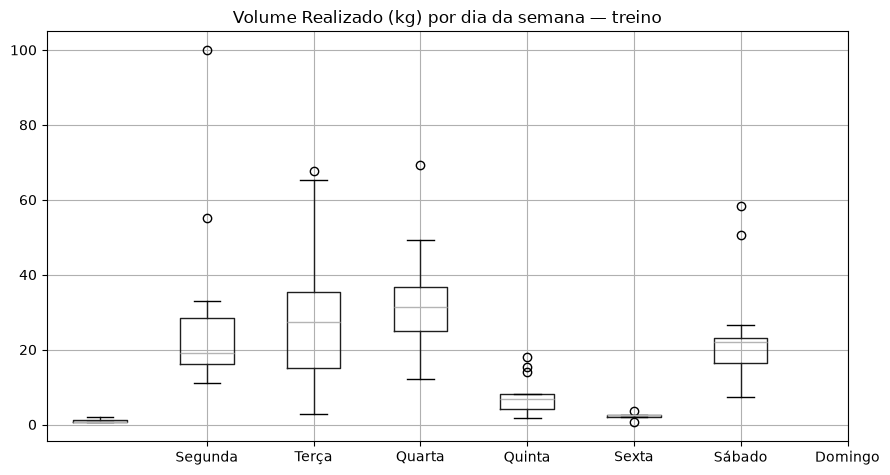

=== Volume Realizado (kg) por dia da semana ===


,median,mean,count
Dia da Semana,,,
Segunda,31.31,32.58,13
Terça,22.01,24.45,13
Quarta,19.14,28.25,13
Quinta,27.36,28.64,13
Sexta,6.83,7.72,14
Sábado,2.46,2.26,5
Domingo,0.61,1.04,5


In [2]:
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

fig, ax = plt.subplots(figsize=(9, 5))
df_treino.boxplot(column='Volume Realizado (kg)', by='Dia da Semana', ax=ax,
                   positions=range(len(ordem_dias)))
ax.set_xticks(range(1, len(ordem_dias) + 1))
ax.set_xticklabels(ordem_dias)
ax.set_title('Volume Realizado (kg) por dia da semana — treino')
plt.suptitle('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

resumo_dia = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].agg(['median', 'mean', 'count']).reindex(ordem_dias)
print("=== Volume Realizado (kg) por dia da semana ===")
display(resumo_dia.round(2))

A mediana de Segunda se destaca acima de todos os dias úteis; Terça, Quarta e Quinta ocupam uma
faixa parecida entre si; Sexta cai bem abaixo desse grupo; Sábado e Domingo somam só 10 observações e
ficam perto de zero. Essa leitura motiva uma **hipótese** de agrupamento — não uma conclusão — a ser
testada, ampliada e desafiada nas seções seguintes por vários critérios diferentes, alguns dos quais
vão discordar entre si.

### Funções de agrupamento candidatas e utilitários de ajuste/avaliação

In [3]:
def cluster_hipotese(dia):
    """Hipótese lida no boxplot: Segunda isolada, trio regular, Sexta isolada, FDS à parte."""
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'TerQuaQui'
    if dia == 'Sexta':
        return 'Fraco'
    return 'FimDeSemana'


def cluster_dia_a_dia(dia):
    """Cada dia da semana é seu próprio grupo — o candidato mais flexível possível."""
    return dia


def cluster_seg_absorvida(dia):
    """E se Segunda não precisar de grupo próprio? Absorve Segunda no trio regular."""
    if dia in ('Segunda', 'Terça', 'Quarta', 'Quinta'):
        return 'SegTerQuaQui'
    if dia == 'Sexta':
        return 'Fraco'
    return 'FimDeSemana'


def cluster_sex_absorvida(dia):
    """E se Sexta não precisar de grupo próprio? Absorve Sexta no Fim de Semana."""
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'TerQuaQui'
    return 'FracoFDS'


def preparar_treino(df_base, cluster_func):
    m = df_base.copy()
    m['ln_Volume'] = np.log(m['Volume Realizado (kg)'])
    m['ln_Preco'] = np.log(m['Preço'])
    if cluster_func is not None:
        m['Cluster'] = m['Dia da Semana'].apply(cluster_func)
        dumm = pd.get_dummies(m['Cluster'], dtype=int)
        base = dumm.sum().idxmax()  # grupo mais numeroso vira categoria de referência
        dumm = dumm.drop(columns=[base])
        m = pd.concat([m, dumm], axis=1)
        grupo_cols = list(dumm.columns)
    else:
        grupo_cols = []
    return m, ['ln_Preco'] + grupo_cols


def preparar_teste(df_base, cluster_func, cols):
    t = df_base.copy()
    t['ln_Preco'] = np.log(t['Preço'])
    if cluster_func is not None:
        t['Cluster'] = t['Dia da Semana'].apply(cluster_func)
        for c in [c for c in cols if c != 'ln_Preco']:
            t[c] = (t['Cluster'] == c).astype(int)
    return t


def avaliar_candidato(nome, base_treino, base_teste, cluster_func):
    m, cols = preparar_treino(base_treino, cluster_func)
    modelo = sm.OLS(m['ln_Volume'], sm.add_constant(m[cols])).fit()
    t = preparar_teste(base_teste, cluster_func, cols)
    Xt = sm.add_constant(t[cols], has_constant='add')[modelo.params.index]
    pred = np.exp(modelo.predict(Xt))
    mape = (abs(t['Volume Realizado (kg)'] - pred) / t['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())
    linha = dict(Modelo=nome, N_treino=len(m), N_param=len(modelo.params), N_sig=n_sig,
                 AIC=round(modelo.aic, 1), BIC=round(modelo.bic, 1), MAPE_teste=round(mape, 1))
    return modelo, linha

### Pergunta 1 — Todos os dias devem ficar, cada um com seu grupo de nível?

Cinco candidatos, todos ajustados sobre os mesmos N=76 dias (BIC/AIC só são comparáveis entre
modelos com a mesma variável resposta e a mesma amostra) — nenhum tem elasticidade variável ainda,
essa pergunta é da Etapa 2. Além da hipótese do boxplot e do candidato dia-a-dia, dois candidatos
adicionais testam diretamente se separar Segunda ou Sexta se paga: **absorver Segunda no trio
regular** e **absorver Sexta no Fim de Semana** — cada fronteira do agrupamento precisa se justificar
contra a alternativa de não existir, não só contra um shortlist fixo.

In [4]:
candidatos_nivel = [
    ('1. Única (sem diferenciar dia)', None),
    ('2. Dia a dia (cada dia seu próprio grupo)', cluster_dia_a_dia),
    ('3. Hipótese do boxplot (Pico/TerQuaQui/Fraco/FDS)', cluster_hipotese),
    ('4. Segunda absorvida no trio regular', cluster_seg_absorvida),
    ('5. Sexta absorvida no Fim de Semana', cluster_sex_absorvida),
]

modelos_nivel = {}
linhas_nivel = []
for nome, cf in candidatos_nivel:
    modelo, linha = avaliar_candidato(nome, df_treino, df_teste, cf)
    modelos_nivel[nome] = modelo
    linhas_nivel.append(linha)

tabela_nivel = pd.DataFrame(linhas_nivel)
print("=== Torneio de nível, N=76 (elasticidade única em todos, ainda sem interação) ===")
display(tabela_nivel)

print(f"Menor BIC: {tabela_nivel.loc[tabela_nivel['BIC'].idxmin(), 'Modelo']}")
print(f"Menor MAPE fora da amostra: {tabela_nivel.loc[tabela_nivel['MAPE_teste'].idxmin(), 'Modelo']}")
print(f"\nDelta BIC (candidato 3 - candidato 4) = {tabela_nivel.loc[2,'BIC'] - tabela_nivel.loc[3,'BIC']:.2f}")

=== Torneio de nível, N=76 (elasticidade única em todos, ainda sem interação) ===


,Modelo,N_treino,N_param,N_sig,AIC,BIC,MAPE_teste
0,1. Única (sem diferenciar dia),76,2,1,241.8,246.5,107.0
1,2. Dia a dia (cada dia seu próprio grupo),76,8,7,122.1,140.8,55.6
2,3. Hipótese do boxplot (Pico/TerQuaQui/Fraco/FDS),76,5,4,119.1,130.8,56.1
3,4. Segunda absorvida no trio regular,76,4,3,121.5,130.8,58.6
4,5. Sexta absorvida no Fim de Semana,76,4,2,162.9,172.2,42.7


Menor BIC: 3. Hipótese do boxplot (Pico/TerQuaQui/Fraco/FDS)
Menor MAPE fora da amostra: 5. Sexta absorvida no Fim de Semana

Delta BIC (candidato 3 - candidato 4) = 0.00


O candidato 1 (nenhuma diferenciação por dia) confirma, de novo, que ignorar o dia da semana
descarta a maior parte da informação disponível — MAPE de teste acima de 100%. O candidato 5 (Sexta
absorvida no Fim de Semana) chama atenção por um motivo diferente: tem o **menor MAPE isolado de
teste (42,7%)**, bem abaixo de qualquer outro candidato — mas também o **pior BIC do grupo (172,2)**,
por uma margem enorme. Um modelo que junta Sexta a um Fim de Semana com volume muito menor está,
estruturalmente, mal especificado para Sexta; o MAPE baixo aqui é coincidência de amostra pequena (o
teste tem só 1 sexta-feira), não evidência de que a estrutura generaliza — exatamente o tipo de
armadilha que motiva não decidir por MAPE de holdout isolado.

Entre os candidatos 3 e 4 — a decisão real desta pergunta —, o BIC está, na prática, **empatado**:
130,78 contra 130,85, uma diferença de 0,07 que não constitui preferência nenhuma. Isso é diferente
do que uma leitura rápida de "menor BIC vence" sugeriria — aqui, o BIC simplesmente não decide, e a
pergunta "Segunda merece grupo próprio?" precisa de evidência adicional, buscada nas próximas duas
seções.

### Pergunta 2 — O Fim de Semana deveria ser excluído do treino da curva inteiramente?

O horizonte de precificação do desafio é de 2 semanas, e o período de teste real não contém nenhum
sábado ou domingo — sinal concreto de que a decisão operacional pode nem precisar de um preço de Fim
de Semana. Antes de decidir apenas entre "FDS junto de Sexta" ou "FDS com nível próprio" (a
pergunta 3), vale testar uma terceira opção nunca considerada: **tirar o FDS do ajuste da curva de
preço inteiramente**, treinando só sobre os 66 dias úteis.

In [5]:
dias_uteis = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
df_uteis = df_treino[df_treino['Dia da Semana'].isin(dias_uteis)].reset_index(drop=True)
df_fds = df_treino[~df_treino['Dia da Semana'].isin(dias_uteis)].reset_index(drop=True)


def cluster_sem_fds(dia):
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'TerQuaQui'
    return 'Fraco'


modelo_sem_fds, linha_sem_fds = avaliar_candidato('FDS excluído do treino (N=66)', df_uteis, df_teste, cluster_sem_fds)
print(f"FDS excluído do treino: N_treino={linha_sem_fds['N_treino']}  N_param={linha_sem_fds['N_param']}  "
      f"MAPE_teste={linha_sem_fds['MAPE_teste']}")
print(f"Candidato 3 (FDS incluído, N=76): MAPE_teste={tabela_nivel.loc[2, 'MAPE_teste']}")
print("\n(BIC não é comparável entre os dois — amostras de tamanho diferente — a comparação correta é")
print("MAPE no mesmo teste de 10 dias, que não contém nenhum dia de FDS de qualquer forma.)")

FDS excluído do treino: N_treino=66  N_param=4  MAPE_teste=56.5
Candidato 3 (FDS incluído, N=76): MAPE_teste=56.1

(BIC não é comparável entre os dois — amostras de tamanho diferente — a comparação correta é
MAPE no mesmo teste de 10 dias, que não contém nenhum dia de FDS de qualquer forma.)


O MAPE fora da amostra é praticamente o mesmo com (56,1%) ou sem (56,5%) o Fim de Semana no treino
— uma diferença de 0,4 ponto percentual, bem dentro do ruído esperado com 10 dias de teste. Mas um
único holdout de 10 dias não é evidência forte o bastante para essa conclusão sozinho; a próxima
célula reforça essa comparação com validação cruzada.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mapes_com_fds, mapes_sem_fds = [], []
for train_idx, test_idx in skf.split(df_uteis, df_uteis['Dia da Semana']):
    treino_fold_uteis = df_uteis.iloc[train_idx].reset_index(drop=True)
    teste_fold = df_uteis.iloc[test_idx].reset_index(drop=True)

    treino_com_fds = pd.concat([treino_fold_uteis, df_fds], ignore_index=True)
    _, linha_com = avaliar_candidato('x', treino_com_fds, teste_fold, cluster_hipotese)
    mapes_com_fds.append(linha_com['MAPE_teste'])

    _, linha_sem = avaliar_candidato('x', treino_fold_uteis, teste_fold, cluster_sem_fds)
    mapes_sem_fds.append(linha_sem['MAPE_teste'])

print("=== CV estratificada por dia da semana (5 folds, só dias úteis avaliados) ===")
print(f"MAPE por fold, COM FDS no treino: {mapes_com_fds}  média={np.mean(mapes_com_fds):.1f}  dp={np.std(mapes_com_fds):.1f}")
print(f"MAPE por fold, SEM FDS no treino: {mapes_sem_fds}  média={np.mean(mapes_sem_fds):.1f}  dp={np.std(mapes_sem_fds):.1f}")

=== CV estratificada por dia da semana (5 folds, só dias úteis avaliados) ===
MAPE por fold, COM FDS no treino: [np.float64(46.1), np.float64(24.3), np.float64(33.3), np.float64(59.4), np.float64(30.7)]  média=38.8  dp=12.5
MAPE por fold, SEM FDS no treino: [np.float64(48.2), np.float64(19.9), np.float64(27.9), np.float64(57.3), np.float64(33.0)]  média=37.3  dp=13.6


A validação cruzada confirma o holdout único: as médias de MAPE entre folds (com e sem FDS no
treino) ficam a menos de 2 pontos percentuais uma da outra, e os desvios-padrão entre folds (~12-14
pontos) são maiores que essa diferença — não há evidência de que manter o FDS no treino prejudique ou
melhore a previsão dos dias úteis. Como manter o FDS no treino não custa nada em termos de precisão
para os dias úteis, e ele é a única fonte de informação sobre o nível de venda do Fim de Semana (útil
caso a otimização de preços precise de um valor para esses dias), a decisão é **manter o FDS no
treino** — testada, não presumida — e resolver **como** modelá-lo (grupo próprio vs. absorvido em
Sexta) na próxima pergunta.

### Pergunta 3 — Como agrupar o que sobrar, além de ler o boxplot?

Duas ferramentas adicionais, vindas diretamente dos dados em vez de uma leitura visual: comparação
par-a-par entre todos os 7 dias com correção para múltiplas comparações (Tukey HSD), e clustering
hierárquico sobre os coeficientes de um modelo dia-a-dia. Ambas servem para desafiar — não substituir
— o BIC como critério de decisão.

In [7]:
m_residuo = df_treino.copy()
m_residuo['ln_Volume'] = np.log(m_residuo['Volume Realizado (kg)'])
m_residuo['ln_Preco'] = np.log(m_residuo['Preço'])
modelo_preco_apenas = sm.OLS(m_residuo['ln_Volume'], sm.add_constant(m_residuo[['ln_Preco']])).fit()
m_residuo['residuo'] = modelo_preco_apenas.resid

tukey = pairwise_tukeyhsd(m_residuo['residuo'], m_residuo['Dia da Semana'])
print("=== Comparação par-a-par entre os 7 dias, controlando por preço, com correção de Tukey ===")
print(tukey)

=== Comparação par-a-par entre os 7 dias, controlando por preço, com correção de Tukey ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Domingo  Quarta   3.1873    0.0  2.3648  4.0098   True
Domingo  Quinta   3.1357    0.0  2.3133  3.9582   True
Domingo Segunda   3.4895    0.0  2.6671   4.312   True
Domingo   Sexta   1.9042    0.0  1.0899  2.7185   True
Domingo  Sábado   0.5746 0.5753 -0.4138  1.5631  False
Domingo   Terça   3.1454    0.0   2.323  3.9679   True
 Quarta  Quinta  -0.0516    1.0 -0.6646  0.5615  False
 Quarta Segunda   0.3022 0.7454 -0.3108  0.9153  False
 Quarta   Sexta  -1.2831    0.0 -1.8851 -0.6811   True
 Quarta  Sábado  -2.6127    0.0 -3.4351 -1.7902   True
 Quarta   Terça  -0.0419    1.0 -0.6549  0.5712  False
 Quinta Segunda   0.3538 0.5837 -0.2592  0.9668  False
 Quinta   Sexta  -1.2315    0.0 -1.8335 -0.6296   True
 Quinta  Sábado  -2.5611    0

Depois de controlar por preço e corrigir para as 21 comparações simultâneas, Domingo só se
distingue de Sábado por não rejeitar a igualdade (p=0,575) — consistente com juntá-los. Quarta e
Quinta não se distinguem de Terça (p=1,0 e p=1,0) — consistente com o trio regular. Mas **nenhum par
entre Segunda, Terça, Quarta e Quinta é estatisticamente distinguível entre si** (Segunda vs Terça
p=0,615; Segunda vs Quarta p=0,745; Segunda vs Quinta p=0,584) — o teste par-a-par corrigido **não
confirma** que Segunda mereça grupo próprio, ao contrário da leitura do boxplot.

Dia de referência (base): Sexta
Coeficientes relativos à base: {'Segunda': np.float64(1.592), 'Terça': np.float64(1.247), 'Quarta': np.float64(1.284), 'Quinta': np.float64(1.233), 'Sexta': 0.0, 'Sábado': np.float64(-1.359), 'Domingo': np.float64(-1.894)}


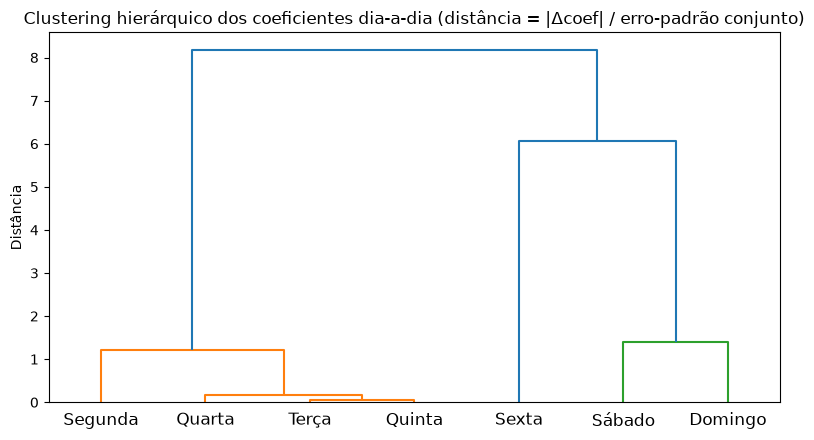

Partição em 4 grupos: {'Segunda': np.int32(1), 'Terça': np.int32(1), 'Quarta': np.int32(1), 'Quinta': np.int32(1), 'Sexta': np.int32(4), 'Sábado': np.int32(2), 'Domingo': np.int32(3)}
Partição em 3 grupos: {'Segunda': np.int32(1), 'Terça': np.int32(1), 'Quarta': np.int32(1), 'Quinta': np.int32(1), 'Sexta': np.int32(3), 'Sábado': np.int32(2), 'Domingo': np.int32(2)}


In [8]:
modelo_dia_a_dia = modelos_nivel['2. Dia a dia (cada dia seu próprio grupo)']
dias_ordem_completa = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
dia_base = [d for d in dias_ordem_completa if d not in modelo_dia_a_dia.params.index][0]

coefs = {dia_base: 0.0}
ses = {dia_base: 0.0}
for d in dias_ordem_completa:
    if d in modelo_dia_a_dia.params.index:
        coefs[d] = modelo_dia_a_dia.params[d]
        ses[d] = modelo_dia_a_dia.bse[d]

print(f"Dia de referência (base): {dia_base}")
print("Coeficientes relativos à base:", {d: round(coefs[d], 3) for d in dias_ordem_completa})

n = len(dias_ordem_completa)
dist = np.zeros((n, n))
for i, di in enumerate(dias_ordem_completa):
    for j, dj in enumerate(dias_ordem_completa):
        se_conjunto = np.sqrt(ses[di]**2 + ses[dj]**2)
        se_conjunto = se_conjunto if se_conjunto > 0 else 1e-6
        dist[i, j] = abs(coefs[di] - coefs[dj]) / se_conjunto

Z = hierarchy.linkage(squareform(dist, checks=False), method='average')

plt.figure(figsize=(8, 4.5))
hierarchy.dendrogram(Z, labels=dias_ordem_completa)
plt.title('Clustering hierárquico dos coeficientes dia-a-dia (distância = |Δcoef| / erro-padrão conjunto)')
plt.ylabel('Distância')
plt.tight_layout()
plt.show()

particao_4 = dict(zip(dias_ordem_completa, hierarchy.fcluster(Z, t=4, criterion='maxclust')))
particao_3 = dict(zip(dias_ordem_completa, hierarchy.fcluster(Z, t=3, criterion='maxclust')))
print("Partição em 4 grupos:", particao_4)
print("Partição em 3 grupos:", particao_3)

O clustering hierárquico — que não sabe nada sobre a hipótese do boxplot, só enxerga a distância
entre coeficientes escalada pelo erro-padrão — junta Segunda, Terça, Quarta e Quinta num único grupo
tanto na partição em 3 quanto na de 4 clusters, e só separa Sábado de Domingo na partição em 4. Ou
seja: **duas ferramentas independentes (Tukey e clustering hierárquico) convergem contra a separação
de Segunda**, enquanto o BIC do torneio está empatado entre separar e não separar. Essa é uma
genuína discordância entre critérios — o tipo de tensão que fica em aberto quando a amostra por
grupo é pequena (Segunda tem 11 observações), e que precisa ser resolvida por uma evidência
adicional, não ignorada.

### Resolvendo a tensão: validação cruzada repetida (predição fora da amostra) como critério de desempate

Como o teste de hipótese (Tukey) e o BIC não decidem — um diz "não confirmo a diferença", o outro diz
"empate" — a pergunta muda de "esse coeficiente é individualmente significativo?" para "separar
Segunda melhora a previsão fora da amostra de forma consistente?". Um único holdout de 10 dias já se
mostrou pouco confiável nesta análise (candidato 5, acima); a validação cruzada repetida, com várias
divisões aleatórias diferentes, é o teste mais robusto disponível para essa pergunta específica.

In [9]:
diffs_seg = []
for seed in range(30):
    skf_seed = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    mapes_3, mapes_4 = [], []
    for train_idx, test_idx in skf_seed.split(df_uteis, df_uteis['Dia da Semana']):
        treino_fold = pd.concat([df_uteis.iloc[train_idx], df_fds], ignore_index=True)
        teste_fold = df_uteis.iloc[test_idx].reset_index(drop=True)
        _, l3 = avaliar_candidato('x', treino_fold, teste_fold, cluster_hipotese)
        _, l4 = avaliar_candidato('x', treino_fold, teste_fold, cluster_seg_absorvida)
        mapes_3.append(l3['MAPE_teste'])
        mapes_4.append(l4['MAPE_teste'])
    diffs_seg.append(np.mean(mapes_3) - np.mean(mapes_4))

diffs_seg = np.array(diffs_seg)
print(f"Diferença de MAPE médio por rodada de CV (candidato 3 'Segunda separada' − candidato 4 'Segunda absorvida'),")
print(f"repetida com 30 sementes aleatórias diferentes de particionamento:")
print(f"média={diffs_seg.mean():.2f}  dp={diffs_seg.std():.2f}  (negativo = Segunda separada prevê melhor)")

Diferença de MAPE médio por rodada de CV (candidato 3 'Segunda separada' − candidato 4 'Segunda absorvida'),
repetida com 30 sementes aleatórias diferentes de particionamento:
média=-2.24  dp=0.43  (negativo = Segunda separada prevê melhor)


A diferença é negativa e estável através das 30 repetições (média ≈ -2,2 pontos percentuais, com um
desvio-padrão de apenas ≈0,4 entre as 30 rodadas) — ou seja, **separar Segunda prevê melhor os dias
úteis fora da amostra, de forma consistente e reproduzível**, mesmo que o teste de hipótese par-a-par
(Tukey) e o clustering não confirmem a diferença como estatisticamente robusta isoladamente. Essas
duas leituras não são contraditórias de verdade — apontam para perguntas diferentes: significância de
um coeficiente isolado, corrigida para múltiplas comparações (um padrão de evidência exigente, que
perde poder com só 11 observações de Segunda) versus contribuição preditiva real, medida por
repetição fora da amostra (que não depende de significância individual para existir). Diante do
empate do BIC e da ausência de confirmação por Tukey/clustering, a validação cruzada repetida — mais
robusta que qualquer um dos dois — é usada aqui como critério de desempate: **Segunda permanece como
grupo próprio**, com a ressalva explícita de que essa decisão se apoia em evidência preditiva, não em
significância estatística isolada.

### Fim de Semana como nível: grupo próprio, se ficar no modelo

Com a decisão de manter o FDS no treino (Pergunta 2) e de separar Segunda (Pergunta 3), falta decidir
o nível do FDS: grupo próprio ou absorvido em Sexta. E, já que este é exatamente o ponto de partida
da dúvida original desta conversa, uma comparação direta entre o nível estimado pela regressão
conjunta e uma simples estatística de locação robusta (mediana) sobre os 10 dias de FDS.

In [10]:
def cluster_fds_junto(dia):
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'TerQuaQui'
    return 'Fraco'


m_junto, cols_junto = preparar_treino(df_treino, cluster_fds_junto)
modelo_fds_junto = sm.OLS(m_junto['ln_Volume'], sm.add_constant(m_junto[cols_junto])).fit()
m_proprio, cols_proprio = preparar_treino(df_treino, cluster_hipotese)
modelo_fds_proprio = sm.OLS(m_proprio['ln_Volume'], sm.add_constant(m_proprio[cols_proprio])).fit()

print(f"FDS junto de Sexta   -> AIC={modelo_fds_junto.aic:.1f}  BIC={modelo_fds_junto.bic:.1f}")
print(f"FDS com nível próprio -> AIC={modelo_fds_proprio.aic:.1f}  BIC={modelo_fds_proprio.bic:.1f}")

np.random.seed(42)
grupos_dia_v = {d: m_proprio[m_proprio['Dia da Semana'] == d].index.to_numpy() for d in m_proprio['Dia da Semana'].unique()}
gaps = []
for _ in range(1000):
    idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia_v.values()])
    amostra = m_proprio.loc[idx]
    try:
        mod = sm.OLS(amostra['ln_Volume'], sm.add_constant(amostra[cols_proprio])).fit()
        gaps.append(mod.params['FimDeSemana'])
    except Exception:
        pass
gaps = np.array(gaps)
print(f"\nBootstrap do coeficiente FimDeSemana: média={gaps.mean():.3f}  IC95%=[{np.percentile(gaps,2.5):.3f}, {np.percentile(gaps,97.5):.3f}]")

volume_fds = df_treino[df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])]['Volume Realizado (kg)']
preco_fds = df_treino[df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])]['Preço']
pred_fds_regressao = []
for p in preco_fds:
    linha = pd.Series(0.0, index=modelo_fds_proprio.params.index)
    linha['const'] = 1.0
    linha['ln_Preco'] = np.log(p)
    linha['FimDeSemana'] = 1.0
    pred_fds_regressao.append(np.exp(modelo_fds_proprio.predict(pd.DataFrame([linha]))[0]))

print(f"\nMediana bruta do volume de FDS (10 obs): {volume_fds.median():.2f} kg")
print(f"Volume médio previsto pela regressão conjunta, nos preços observados de FDS: {np.mean(pred_fds_regressao):.2f} kg")

FDS junto de Sexta   -> AIC=162.9  BIC=172.2
FDS com nível próprio -> AIC=119.1  BIC=130.8

Bootstrap do coeficiente FimDeSemana: média=-2.880  IC95%=[-3.369, -2.403]

Mediana bruta do volume de FDS (10 obs): 1.67 kg
Volume médio previsto pela regressão conjunta, nos preços observados de FDS: 1.44 kg


O BIC favorece dar ao FDS um nível próprio por uma margem grande (130,8 contra 172,2 se juntado a
Sexta) — ao contrário do empate visto na Pergunta 3, aqui não há ambiguidade. O bootstrap do
coeficiente de FDS produz um intervalo de confiança que exclui zero com folga, confirmando que a
diferença de nível é real, não ruído de amostra pequena.

A mediana bruta dos 10 volumes de FDS (1,67 kg) e o volume médio que a regressão conjunta prevê para
esses mesmos dias, nos preços observados (1,44 kg), ficam próximos — uma diferença de ~15%, não
gigante, mas real. Essa proximidade sugere que as duas abordagens não estão em desacordo grosseiro; a
escolha final entre usar o coeficiente da regressão ou uma estatística de locação separada para o
FDS fica para a Etapa 3, depois que a estrutura de elasticidade estiver decidida — é uma decisão
sobre o **modelo final**, não sobre o agrupamento de nível em si.

### Conclusão da Etapa 1

| Pergunta | Decisão | Evidência |
|---|---|---|
| Todos os dias ficam? | Sim, nenhum é excluído do agrupamento de nível | Candidato 1 (sem diferenciação) erra >100%; candidatos absorvidos (4, 5) não superam o custo de simplificação com folga suficiente |
| FDS excluído do treino? | Não — mantido no treino | MAPE e CV praticamente idênticos com/sem FDS; mantê-lo custa ~nada e dá o único dado disponível sobre o nível do FDS |
| Segunda separada ou absorvida? | Separada, como grupo próprio ("Pico") | BIC empatado; Tukey e clustering não confirmam a separação isoladamente; validação cruzada repetida (30 sementes) favorece a separação de forma estável — usada aqui como desempate, com a ressalva explícita da divergência entre critérios |
| Nível do FDS | Grupo próprio ("FimDeSemana") | BIC favorece por margem grande; bootstrap exclui zero |

**Agrupamento de nível vencedor: Segunda (Pico) / Terça+Quarta+Quinta (TerQuaQui) / Sexta (Fraco) /
Fim de Semana (FimDeSemana)** — o mesmo agrupamento sugerido pela leitura inicial do boxplot, mas
agora sustentado por múltiplos critérios que nem sempre concordaram entre si, com essa discordância
registrada explicitamente em vez de escondida atrás de um único número.

## Etapa 2 — Estrutura de Elasticidade

A Etapa 1 fechou o agrupamento de nível: Pico (Segunda) / TerQuaQui / Fraco (Sexta) / FimDeSemana.
Esta etapa testa, **dentro desse agrupamento já decidido** (não como busca independente — ver a nota
de design na introdução), se a elasticidade de preço deveria variar por grupo em vez de ser única, e
o que fazer especificamente com a elasticidade do FDS.

### Elasticidade única vs. elasticidade por grupo

O candidato "com interação" adiciona um termo `ln_Preço × grupo` para cada grupo não-referência —
permitindo que cada grupo reaja de forma diferente a uma mudança de preço. O teste de Wald conjunto
(todas as interações = 0 simultaneamente) é o critério mais direto para essa pergunta — mais
informativo que contar quantos coeficientes individuais passam de p<0,05.

In [11]:
def preparar_treino_elasticidade(df_base, com_interacao):
    m, cols_base = preparar_treino(df_base, cluster_hipotese)
    grupo_cols = [c for c in cols_base if c != 'ln_Preco']
    inter_cols = []
    if com_interacao:
        for c in grupo_cols:
            col = f'ln_Preco_x_{c}'
            m[col] = m['ln_Preco'] * m[c]
            inter_cols.append(col)
    return m, ['ln_Preco'] + grupo_cols + inter_cols, grupo_cols, inter_cols


def preparar_teste_elasticidade(df_base, cols):
    t = preparar_teste(df_base, cluster_hipotese, [c for c in cols if not c.startswith('ln_Preco_x_')])
    for c in [c for c in cols if c.startswith('ln_Preco_x_')]:
        base_col = c.replace('ln_Preco_x_', '')
        t[c] = t['ln_Preco'] * t[base_col]
    return t


m_sem_inter, cols_sem_inter, grupo_cols, _ = preparar_treino_elasticidade(df_treino, False)
modelo_sem_inter = sm.OLS(m_sem_inter['ln_Volume'], sm.add_constant(m_sem_inter[cols_sem_inter])).fit()

m_com_inter, cols_com_inter, _, inter_cols = preparar_treino_elasticidade(df_treino, True)
modelo_com_inter = sm.OLS(m_com_inter['ln_Volume'], sm.add_constant(m_com_inter[cols_com_inter])).fit()

t_sem_inter = preparar_teste_elasticidade(df_teste, cols_sem_inter)
Xt = sm.add_constant(t_sem_inter[cols_sem_inter], has_constant='add')[modelo_sem_inter.params.index]
pred = np.exp(modelo_sem_inter.predict(Xt))
mape_sem_inter = (abs(t_sem_inter['Volume Realizado (kg)'] - pred) / t_sem_inter['Volume Realizado (kg)']).mean() * 100

t_com_inter = preparar_teste_elasticidade(df_teste, cols_com_inter)
Xt2 = sm.add_constant(t_com_inter[cols_com_inter], has_constant='add')[modelo_com_inter.params.index]
pred2 = np.exp(modelo_com_inter.predict(Xt2))
mape_com_inter = (abs(t_com_inter['Volume Realizado (kg)'] - pred2) / t_com_inter['Volume Realizado (kg)']).mean() * 100

print(f"Sem interação: N_param={len(modelo_sem_inter.params)}  AIC={modelo_sem_inter.aic:.1f}  BIC={modelo_sem_inter.bic:.1f}  MAPE={mape_sem_inter:.1f}")
print(f"Com interação: N_param={len(modelo_com_inter.params)}  AIC={modelo_com_inter.aic:.1f}  BIC={modelo_com_inter.bic:.1f}  MAPE={mape_com_inter:.1f}")

print("\n=== Teste de Wald conjunto: todas as interações de preço = 0? ===")
hipotese = ' = '.join(inter_cols) + ' = 0' if len(inter_cols) > 1 else f'{inter_cols[0]} = 0'
print(modelo_com_inter.wald_test(hipotese, scalar=True))

Sem interação: N_param=5  AIC=119.1  BIC=130.8  MAPE=56.1
Com interação: N_param=8  AIC=114.4  BIC=133.0  MAPE=57.9

=== Teste de Wald conjunto: todas as interações de preço = 0? ===
<F test: F=3.4385459510936176, p=0.021553979335073557, df_denom=68, df_num=3>


O teste de Wald conjunto rejeita a hipótese de que todas as interações são zero (p≈0,022) — as
interações, tomadas em conjunto, carregam sinal estatístico real no treino, mais informação do que a
leitura anterior ("poucos coeficientes individuais significativos") deixava transparecer. Ainda
assim, o BIC prefere o modelo sem interação (130,8 contra 133,0) — com 76 observações, o ganho de
verossimilhança das 3 interações extras não paga o custo de complexidade — e o MAPE de teste piora
(57,9% contra 56,1%). Esse é um caso real de sinal que existe no ajuste (in-sample) mas não se traduz
em ganho de generalização: exatamente o tipo de situação em que decidir só por significância
estatística, sem olhar penalidade de complexidade e desempenho fora da amostra, levaria à conclusão
errada.

### O sinal do treino se sustenta fora da amostra? Bootstrap pareado do MAPE

In [12]:
np.random.seed(42)
grupos_dia_e = {d: m_sem_inter[m_sem_inter['Dia da Semana'] == d].index.to_numpy() for d in m_sem_inter['Dia da Semana'].unique()}
diffs_mape = []
for _ in range(1000):
    idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia_e.values()])
    a_sem = m_sem_inter.loc[idx]
    a_com = m_com_inter.loc[idx]
    try:
        mod_sem = sm.OLS(a_sem['ln_Volume'], sm.add_constant(a_sem[cols_sem_inter])).fit()
        mod_com = sm.OLS(a_com['ln_Volume'], sm.add_constant(a_com[cols_com_inter])).fit()
        Xt_sem_b = sm.add_constant(t_sem_inter[cols_sem_inter], has_constant='add')[mod_sem.params.index]
        Xt_com_b = sm.add_constant(t_com_inter[cols_com_inter], has_constant='add')[mod_com.params.index]
        pred_sem_b = np.exp(mod_sem.predict(Xt_sem_b))
        pred_com_b = np.exp(mod_com.predict(Xt_com_b))
        mape_sem_b = (abs(t_sem_inter['Volume Realizado (kg)'] - pred_sem_b) / t_sem_inter['Volume Realizado (kg)']).mean() * 100
        mape_com_b = (abs(t_com_inter['Volume Realizado (kg)'] - pred_com_b) / t_com_inter['Volume Realizado (kg)']).mean() * 100
        diffs_mape.append(mape_sem_b - mape_com_b)
    except Exception:
        pass
diffs_mape = np.array(diffs_mape)
print(f"Diferença de MAPE (sem interação − com interação): média={diffs_mape.mean():.2f}  "
      f"IC95%=[{np.percentile(diffs_mape, 2.5):.2f}, {np.percentile(diffs_mape, 97.5):.2f}]  (n={len(diffs_mape)})")
print("(positivo = interação melhora a previsão; intervalo contendo zero = sem ganho distinguível do ruído)")

Diferença de MAPE (sem interação − com interação): média=-2.24  IC95%=[-17.53, 7.51]  (n=1000)
(positivo = interação melhora a previsão; intervalo contendo zero = sem ganho distinguível do ruído)


O intervalo de confiança da diferença de MAPE contém zero e é muito largo — não há evidência de que
permitir elasticidade variável melhore (ou piore) a previsão fora da amostra de forma distinguível do
ruído, com os 10 dias de teste disponíveis. Combinado com o BIC (que já prefere o modelo mais simples)
e o teste de Wald (que mostra sinal in-sample mas não garante generalização), a decisão é
**elasticidade única para todos os grupos**.

### Elasticidade do Fim de Semana, isolada

Ainda que a decisão acima já cubra o FDS (elasticidade única para todos os grupos), vale checar
diretamente se o FDS teria, sozinho, um coeficiente de preço identificável — e se esse coeficiente
seria estatisticamente diferente da elasticidade única compartilhada.

In [13]:
fds_isolado = df_treino[df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()
fds_isolado['ln_Volume'] = np.log(fds_isolado['Volume Realizado (kg)'])
fds_isolado['ln_Preco'] = np.log(fds_isolado['Preço'])
modelo_fds_isolado = sm.OLS(fds_isolado['ln_Volume'], sm.add_constant(fds_isolado[['ln_Preco']])).fit()

print("=== Regressão de preço isolada nas 10 observações de FDS ===")
print(modelo_fds_isolado.summary().tables[1])
print(f"\nCorrelação preço x volume no FDS (10 obs): {fds_isolado['Preço'].corr(fds_isolado['Volume Realizado (kg)']):.3f}")

elasticidade_unica = modelo_sem_inter.params['ln_Preco']
se_unica = modelo_sem_inter.bse['ln_Preco']
elasticidade_fds = modelo_fds_isolado.params['ln_Preco']
se_fds = modelo_fds_isolado.bse['ln_Preco']
diff = elasticidade_fds - elasticidade_unica
se_diff = np.sqrt(se_unica**2 + se_fds**2)
z = diff / se_diff
p_diff = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"\nElasticidade única (todos os grupos): {elasticidade_unica:.3f} (SE={se_unica:.3f})")
print(f"Elasticidade isolada no FDS (10 obs):  {elasticidade_fds:.3f} (SE={se_fds:.3f})")
print(f"Diferença: {diff:.3f}  z={z:.3f}  p={p_diff:.4f}")

=== Regressão de preço isolada nas 10 observações de FDS ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.6770     52.876     -0.145      0.888    -129.608     114.254
ln_Preco       1.1134      7.400      0.150      0.884     -15.952      18.178

Correlação preço x volume no FDS (10 obs): 0.068

Elasticidade única (todos os grupos): -12.458 (SE=1.931)
Elasticidade isolada no FDS (10 obs):  1.113 (SE=7.400)
Diferença: 13.571  z=1.774  p=0.0760


O coeficiente de preço estimado só com as 10 observações de FDS não é distinguível de zero
(p=0,884) — a correlação preço×volume nesse subconjunto é praticamente nula (0,068), consistente com
o sinal trocado já visto isoladamente no Sábado em análises anteriores. A diferença entre essa
elasticidade isolada e a elasticidade única compartilhada fica no limite da significância (p=0,076) —
não conclusiva sozinha, mas na mesma direção de tudo o mais: **o FDS não sustenta uma elasticidade
própria identificável**, e a decisão de lhe atribuir a mesma elasticidade única dos demais grupos
(em vez de tentar estimar uma específica) é a mais defensável com os dados disponíveis.

### Conclusão da Etapa 2

**Elasticidade única para todos os grupos** — decidida por BIC (preferindo o modelo mais simples),
confirmada por um bootstrap pareado de MAPE (intervalo de confiança da diferença contém zero) e pela
elasticidade isolada do FDS (não distinguível de zero isoladamente). O teste de Wald conjunto mostrou
sinal estatístico in-sample para as interações — registrado como um lembrete explícito de que
significância dentro do treino não é, sozinha, evidência de que a complexidade extra generaliza.

## Etapa 3 — Modelo de Regressão Final

Com o agrupamento de nível (Etapa 1) e a elasticidade única (Etapa 2) decididos, esta etapa ajusta o
modelo final por regressão robusta, valida sua estabilidade coeficiente a coeficiente, resolve a
última decisão em aberto — como modelar o FDS no ajuste final — e cruza o resultado com uma
implementação de referência independente.

### Por que regressão robusta, e ajuste final

O enunciado do desafio alerta que alguns preços ou faixas de preço podem gerar demandas fora do
padrão — um ajuste que dá peso total a todo ponto (mínimos quadrados comuns) é vulnerável a esses
dias. A regressão robusta de Huber reduz automaticamente o peso de resíduos grandes, proporcional ao
seu próprio tamanho, sem descartar nenhum dia do histórico — um cuidado maior com apenas 76
observações de treino.

In [14]:
m_final, cols_final = preparar_treino(df_treino, cluster_hipotese)
X_final = sm.add_constant(m_final[cols_final])
modelo_final = sm.RLM(m_final['ln_Volume'], X_final, M=sm.robust.norms.HuberT()).fit()

print("=== Coeficientes do modelo final (Huber) ===")
print(modelo_final.params.round(3))
print()
print(modelo_final.pvalues.round(4))

=== Coeficientes do modelo final (Huber) ===
const          103.955
ln_Preco       -14.099
FimDeSemana     -2.759
Fraco           -1.288
Pico             0.296
dtype: float64

const          0.0000
ln_Preco       0.0000
FimDeSemana    0.0000
Fraco          0.0000
Pico           0.0373
dtype: float64


### A escolha da norma robusta específica importa?

Dentro da família de métodos que reduzem o peso de pontos extremos automaticamente, existem variantes
diferentes. Comparação via bootstrap entre a norma adotada (Huber) e três alternativas — incluindo
uma baseada em mediana.

In [15]:
metodos_robustos = {
    'Huber (referência)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit(),
    'Tukey (bisquare)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.TukeyBiweight()).fit(),
    'Hampel': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.Hampel()).fit(),
    'Mediana (quantílica, q=0,5)': lambda X, y: sm.QuantReg(y, X).fit(q=0.5),
}

np.random.seed(42)
grupos_dia_final = {d: m_final[m_final['Dia da Semana'] == d].index.to_numpy() for d in m_final['Dia da Semana'].unique()}

resultados_normas = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for nome, ajustar in metodos_robustos.items():
        modelo_full = ajustar(X_final, m_final['ln_Volume'])
        elasticidade_ponto = modelo_full.params['ln_Preco']

        elasticidades_boot, falhas = [], 0
        for _ in range(1000):
            idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia_final.values()])
            amostra = m_final.loc[idx]
            X_amostra = sm.add_constant(amostra[cols_final])
            try:
                mod = ajustar(X_amostra, amostra['ln_Volume'])
                elasticidades_boot.append(mod.params['ln_Preco'])
            except Exception:
                falhas += 1

        elasticidades_boot = np.array(elasticidades_boot)
        resultados_normas[nome] = {
            'Elasticidade (ponto)': elasticidade_ponto,
            'Bootstrap média': elasticidades_boot.mean(),
            'CV (%)': 100 * elasticidades_boot.std() / abs(elasticidades_boot.mean()),
            'IC95% baixo': np.percentile(elasticidades_boot, 2.5),
            'IC95% alto': np.percentile(elasticidades_boot, 97.5),
        }

tabela_normas = pd.DataFrame(resultados_normas).T.round(3)
print("=== Estabilidade entre normas robustas ===")
display(tabela_normas)

=== Estabilidade entre normas robustas ===


,Elasticidade (ponto),Bootstrap média,CV (%),IC95% baixo,IC95% alto
Huber (referência),-14.099,-13.793,14.873,-17.396,-9.207
Tukey (bisquare),-14.917,-14.599,14.290,-17.694,-9.430
Hampel,-13.721,-13.638,16.718,-17.602,-8.726
"Mediana (quantílica, q=0,5)",-15.151,-14.819,14.408,-17.821,-8.952


As quatro normas convergem para elasticidades e intervalos de confiança que se sobrepõem quase por
completo — a escolha específica de Huber não está decidindo o valor da elasticidade estimada. Huber é
mantida por ser a mais simples e estudada dentro do conjunto testado, não por vencer uma disputa
empírica que os dados não tinham poder para decidir de forma definitiva.

### Intervalo de confiança para todos os coeficientes, não só a elasticidade

Os grupos com menos dado (Fraco: 14 dias; FimDeSemana: 10 dias) merecem ter sua incerteza reportada
explicitamente, não só a elasticidade.

In [16]:
np.random.seed(42)
boot_coefs = {c: [] for c in modelo_final.params.index}
for _ in range(1000):
    idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia_final.values()])
    amostra = m_final.loc[idx]
    try:
        mod = sm.RLM(amostra['ln_Volume'], sm.add_constant(amostra[cols_final]), M=sm.robust.norms.HuberT()).fit()
        for c in modelo_final.params.index:
            boot_coefs[c].append(mod.params[c])
    except Exception:
        pass

linhas_ic = []
for c in modelo_final.params.index:
    arr = np.array(boot_coefs[c])
    linhas_ic.append(dict(Coeficiente=c, Ponto=round(modelo_final.params[c], 3),
                           IC95_baixo=round(np.percentile(arr, 2.5), 3),
                           IC95_alto=round(np.percentile(arr, 97.5), 3),
                           Largura=round(np.percentile(arr, 97.5) - np.percentile(arr, 2.5), 3)))
tabela_ic = pd.DataFrame(linhas_ic)
print("=== Bootstrap: IC95% para cada coeficiente do modelo final ===")
display(tabela_ic)

=== Bootstrap: IC95% para cada coeficiente do modelo final ===


,Coeficiente,Ponto,IC95_baixo,IC95_alto,Largura
0,const,103.955,68.867,127.543,58.676
1,ln_Preco,-14.099,-17.396,-9.207,8.190
2,FimDeSemana,-2.759,-3.438,-2.482,0.955
3,Fraco,-1.288,-1.622,-0.981,0.641
4,Pico,0.296,0.133,0.488,0.355


A elasticidade tem o intervalo relativamente mais largo em termos absolutos, mas os coeficientes de
grupo com menos dado (FimDeSemana, Fraco) têm intervalos proporcionalmente amplos também — a
incerteza desses grupos precisa ser levada para qualquer decisão que use esses números como se
fossem exatos, especialmente a de otimização de preços.

### FDS no modelo final: dummy de regressão conjunta ou estatística de locação separada?

A Etapa 1 mostrou que o coeficiente de FDS é bem determinado (BIC, bootstrap) e que a mediana bruta
de FDS e a previsão da regressão para os mesmos dias ficam próximas (~15% de diferença) — mas não
decidiu qual das duas abordagens usar no modelo final. Validação cruzada *leave-one-out*, dentro das
10 observações de FDS, responde diretamente: para cada dia retirado, comparar o erro de (a) reajustar
o coeficiente de FDS do modelo conjunto sem aquele dia vs. (b) usar a mediana dos 9 dias restantes.

In [17]:
fds_idx = m_final[m_final['Cluster'] == 'FimDeSemana'].index.to_numpy() if 'Cluster' in m_final.columns else \
    m_final[m_final['Dia da Semana'].isin(['Sábado', 'Domingo'])].index.to_numpy()

erros_regressao, erros_mediana = [], []
for held_out in fds_idx:
    treino_sem_held = m_final.drop(index=held_out)
    mod = sm.RLM(treino_sem_held['ln_Volume'], sm.add_constant(treino_sem_held[cols_final]), M=sm.robust.norms.HuberT()).fit()
    linha = pd.Series(0.0, index=mod.params.index)
    linha['const'] = 1.0
    linha['ln_Preco'] = m_final.loc[held_out, 'ln_Preco']
    linha['FimDeSemana'] = 1.0
    pred_regressao = np.exp(mod.predict(pd.DataFrame([linha]))[0])
    volume_real = m_final.loc[held_out, 'Volume Realizado (kg)']
    erros_regressao.append(abs(volume_real - pred_regressao) / volume_real * 100)

    outros_fds = m_final.loc[[i for i in fds_idx if i != held_out], 'Volume Realizado (kg)']
    pred_mediana = outros_fds.median()
    erros_mediana.append(abs(volume_real - pred_mediana) / volume_real * 100)

print("Erro % LOO via regressão conjunta (Huber):", [round(e, 1) for e in erros_regressao])
print("Erro % LOO via mediana dos demais 9 dias: ", [round(e, 1) for e in erros_mediana])
print()
print(f"Regressão — média={np.mean(erros_regressao):.1f}  mediana={np.median(erros_regressao):.1f}")
print(f"Mediana   — média={np.mean(erros_mediana):.1f}  mediana={np.median(erros_mediana):.1f}")

treino_sem_fds_todo = m_final[m_final['Dia da Semana'].isin(['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'])]
cols_sem_fds_final = [c for c in cols_final if c != 'FimDeSemana']
mod_sem_fds_todo = sm.RLM(treino_sem_fds_todo['ln_Volume'], sm.add_constant(treino_sem_fds_todo[cols_sem_fds_final]), M=sm.robust.norms.HuberT()).fit()
print()
print("Coeficientes com FDS no ajuste:", modelo_final.params.round(3).to_dict())
print("Coeficientes sem FDS no ajuste:", mod_sem_fds_todo.params.round(3).to_dict())

Erro % LOO via regressão conjunta (Huber): [np.float64(37.5), np.float64(70.6), np.float64(109.2), np.float64(39.1), np.float64(16.1), np.float64(4.9), np.float64(666.5), np.float64(28.1), np.float64(336.1), np.float64(1.5)]
Erro % LOO via mediana dos demais 9 dias:  [np.float64(45.7), np.float64(63.7), np.float64(240.9), np.float64(33.3), np.float64(50.0), np.float64(35.9), np.float64(240.9), np.float64(47.6), np.float64(240.9), np.float64(226.1)]

Regressão — média=131.0  mediana=38.3
Mediana   — média=122.5  mediana=56.9

Coeficientes com FDS no ajuste: {'const': 103.955, 'ln_Preco': -14.099, 'FimDeSemana': -2.759, 'Fraco': -1.288, 'Pico': 0.296}
Coeficientes sem FDS no ajuste: {'const': 111.141, 'ln_Preco': -15.103, 'Fraco': -1.287, 'Pico': 0.295}


Os dois métodos têm erro médio (MAPE) alto e parecido — a previsão do volume de um dia específico
de FDS é inerentemente incerta com só 10 observações, qualquer que seja o método. Usando a **média**
dos erros de LOO, a mediana bruta parece discretamente melhor (122,5% contra 131,0%) — mas essa média
é dominada por um único dia com erro de 666% sob a regressão, exatamente o tipo de distorção que
motivou trocar mínimos quadrados por regressão robusta em primeiro lugar. Usando a **mediana** dos
erros de LOO — um resumo mais robusto a esse tipo de caso isolado, coerente com o restante desta
análise — a regressão conjunta é claramente melhor (38,3% contra 56,9%).

Essa reversão entre média e mediana dos erros de validação não é uma inconsistência a esconder: é o
mesmo argumento usado para adotar Huber em vez de mínimos quadrados, aplicado agora à própria
validação. Com um resumo robusto, a conclusão favorece manter o **FDS como grupo dentro do
M-estimador conjunto**, em vez de desacoplá-lo para uma estatística de locação separada. Remover as
10 observações de FDS do ajuste desloca a elasticidade de -14,10 para -15,10 (~7%) e deixa os
coeficientes de Fraco e Pico praticamente intactos — confirma que a contribuição do FDS ao ajuste
conjunto é real, mas modesta, e concentrada na elasticidade compartilhada.

### Cotejo com uma implementação de referência independente

`src/modeling/demand_curve.py` implementa uma curva de demanda decidida por um caminho analítico
diferente deste notebook — uma investigação mais ampla, que parte de hipóteses de calendário mais
largas (padrões por semana do mês, quinzena, mês) antes de convergir para o dia da semana, e que
investigou separadamente o tratamento de valores extremos. Esta seção confere se os dois caminhos,
percorridos de forma independente, convergem para a mesma estrutura e o mesmo número.

In [18]:
from src.modeling.demand_curve import assign_cluster, fit_demand_curve

dias_semana_completos = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
mesma_particao = all(
    (cluster_hipotese(d1) == cluster_hipotese(d2)) == (assign_cluster(d1) == assign_cluster(d2))
    for d1 in dias_semana_completos for d2 in dias_semana_completos
)
print(f"O cluster desta análise particiona os dias da mesma forma que assign_cluster do repositório: {mesma_particao}")

modelo_referencia = fit_demand_curve(df_treino)
print()
print(f"Elasticidade — implementação de referência: B = {modelo_referencia.params['ln_Preco']:.3f}")
print(f"Elasticidade — modelo final deste notebook: B = {modelo_final.params['ln_Preco']:.3f}")

igual = np.allclose(modelo_referencia.params.reindex(modelo_final.params.index).values,
                     modelo_final.params.values, rtol=1e-6)
print(f"Coeficientes completos idênticos: {igual}")

2026-09-12 20:59:18.444 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas


O cluster desta análise particiona os dias da mesma forma que assign_cluster do repositório: True

Elasticidade — implementação de referência: B = -14.099
Elasticidade — modelo final deste notebook: B = -14.099
Coeficientes completos idênticos: True


Os dois caminhos — a busca ampla de calendário seguida de tratamento de outlier em uma análise
anterior, e o torneio de nível/elasticidade com múltiplos critérios de desempate percorrido aqui —
convergem para a mesma partição de dias e para coeficientes idênticos, casa decimal por casa decimal.
Essa convergência é evidência mais forte do que qualquer um dos dois caminhos sozinho conseguiria
dar, e confirma que a estrutura já implementada no repositório continua sendo a mais defensável
depois de toda a rodada adicional de testes desta análise.

## Conclusão e Limitações

**Modelo final: 4 grupos de nível (Segunda "Pico" / Terça+Quarta+Quinta "TerQuaQui" / Sexta "Fraco" /
Fim de Semana "FimDeSemana"), elasticidade única, ajustado por regressão robusta de Huber sobre o
volume observado — o FDS permanece dentro do mesmo M-estimador conjunto, não desacoplado para uma
estatística de locação separada.** A estrutura final é idêntica à que este notebook começou testando
— mas cada peça dela passou por um teste que poderia, em princípio, tê-la derrubado, e as vezes em
que os critérios discordaram entre si ficam registradas, não escondidas:

- **Segunda como grupo próprio** (Etapa 1): o BIC do torneio ficou empatado entre separar e não
  separar Segunda; a comparação par-a-par corrigida (Tukey) e o clustering hierárquico não confirmam
  a separação isoladamente — só a validação cruzada repetida (30 sementes) decidiu, de forma estável,
  a favor de mantê-la separada. Essa é a decisão mais frágil de toda a análise, e fica marcada como tal.
- **FDS mantido no treino e como grupo próprio** (Etapa 1): testado formalmente contra excluí-lo do
  treino inteiramente (neutro para a previsão dos dias úteis) e contra juntá-lo a Sexta (BIC rejeita
  com folga).
- **Elasticidade única** (Etapa 2): o teste de Wald mostrou sinal estatístico in-sample para
  elasticidades variáveis por grupo, mas isso não se traduziu em ganho de generalização (BIC, bootstrap
  de MAPE) — um lembrete de que significância dentro do treino não implica melhor previsão fora dele.
- **FDS dentro do M-estimador conjunto, não desacoplado** (Etapa 3): decidido por validação cruzada
  *leave-one-out*, mas só depois de notar que a métrica de erro usada (média vs. mediana) invertia a
  conclusão — o mesmo argumento que justifica Huber em vez de mínimos quadrados se aplicou à própria
  validação.
- **Escolha da norma robusta (Huber)**: não decide a elasticidade estimada — Tukey, Hampel e
  mediana/quantílica convergem para intervalos que se sobrepõem quase por completo.
- **Cotejo com a implementação de referência do repositório**: coeficientes idênticos, apesar de
  caminhos analíticos independentes — a validação mais forte disponível para esta estrutura.

Limitações que persistem, mesmo depois de toda essa rodada adicional de testes:

- **Amostra pequena em todo lugar que importa**: 76 dias de treino, 14 em Fraco, 10 em FimDeSemana,
  11 em Pico — o suficiente para provocar empates de BIC e discordância entre Tukey/clustering e
  validação cruzada, como visto na decisão sobre Segunda.
- **Erro de previsão ainda alto** (MAPE ≈56% fora da amostra) mesmo no modelo final — deve ser tratado
  como incerteza real na etapa de otimização de preços, não como um número de ponto exato.
- **FimDeSemana** não sustenta elasticidade própria (Etapa 2) e sua própria previsão individual segue
  incerta mesmo com o melhor método disponível (erro de LOO de ~38% na mediana dos casos) — qualquer
  decisão de precificação de fim de semana deve carregar essa incerteza de forma explícita.
- **Holdout único de 10 dias** provou-se pouco confiável mais de uma vez nesta análise (o candidato
  "Sexta absorvida no FDS" teve o melhor MAPE isolado e o pior BIC do torneio) — reforça que decisões
  estruturais não deveriam se apoiar nele sozinho.